In [1]:
#import packages
import time
import numpy as np
from typing import *
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import plotly.graph_objects as go
from scipy.optimize import curve_fit
from scipy.interpolate import splprep, splev
import csv
import os
from NIDAQ import USB6363
import nidaqmx
from nidaqmx.constants import AcquisitionType
from nidaqmx.constants import Edge
from src.DieTesterInstrument import *
from src.FirstLightController import *
from src.ChipAlignmentController import ChipAlignmentController
from src.NIDAQPowermeter import PowermeterSystem
from src.SoftwareFence import SoftwareFence
from src.AutoAlignController import WaveguideAlignmentController
from src.StageControlGUI import StageControlGUI
from src.ScanGUI import ScanControlGUI
import SantecTunableLaser
print(dir(SantecTunableLaser))
#list ASRLs
import pyvisa
rm = pyvisa.ResourceManager()
rm.list_resources(query ='?*') # to make sure all the Suruga stages are connected


['TSL', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'pyvisa', 'time']


('USB0::0x0957::0x3718::MY51350815::0::INSTR',
 'USB0::0x1313::0x8031::M01066988::0::INSTR',
 'TCPIP0::K-EXR608A-60117::hislip0::INSTR',
 'TCPIP0::K-EXR608A-60117::inst0::INSTR',
 'TCPIP0::K-EXR608A-60117::5025::SOCKET',
 'TCPIP0::K-N7749C-00104::inst0::INSTR',
 'TCPIP0::K-N7749C-00104::5025::SOCKET',
 'TCPIP0::K-N7749C-00104::hislip0::INSTR',
 'TCPIP0::K-N7786C-00222::inst0::INSTR',
 'TCPIP0::K-N7786C-00222::5025::SOCKET',
 'TCPIP0::K-N7786C-00222::hislip0::INSTR',
 'TCPIP0::K-N7742C-00112::inst0::INSTR',
 'TCPIP0::K-N7742C-00112::5025::SOCKET',
 'TCPIP0::K-N7742C-00112::hislip0::INSTR',
 'TCPIP0::K-N7776C-00505::inst0::INSTR',
 'TCPIP0::K-N7776C-00505::5025::SOCKET',
 'TCPIP0::K-N7776C-00505::hislip0::INSTR',
 'ASRL1::INSTR',
 'ASRL3::INSTR',
 'ASRL17::INSTR',
 'ASRL18::INSTR',
 'ASRL19::INSTR',
 'ASRL20::INSTR')

In [3]:
#@ Die Tester Stage and Powermeter + Motion I/O

try:
    stg.close()
    pm.close()
    time.sleep(1)
    del stg
    del pm
except:
    0

# stg = DieTesterStage(9, 11, 8, 10)
stg = DieTesterStage(17, 20, 18, 19)
# stg = DieTesterStage(19, 20, 21, 22) # before moving: 13, 15, 5, 4
ai_channel = 'ai1'
pm = PowermeterSystem('Dev1', 5e3, ai_channel) # needs Dev1 for the raster to work

Connected to: SURUGA,DS102,0,VER4.00
Connected to: SURUGA,DS102,0,VER4.00
Connected to: SURUGA,DS102,0,VER4.00
Connected to: SURUGA,DS102,0,VER4.00
AIChannel(name=Dev1/ai1)
Connected to: NI DAQ, Dev1, USB-6363 (BNC)


In [6]:
# testing USB connection
TSL770 = SantecTunableLaser.TSL('TCPIP0::10.101.0.157::64000::SOCKET') # LAN
TSL770.timeout = 5000

In [7]:
# Initialize switch
# address = 'TCPIP0::10.101.0.199::5025::INSTR' # N7731A
address = 'USB0::0x0957::0x3718::MY51350815::INSTR' # N7731A
# address = 'USB0::0x0957::0x3718::MY51350266::INSTR' # N7734A 
# USB0::0x0957::0x3718::MY51350815::0::INSTR

rm = pyvisa.ResourceManager()
switch = rm.open_resource(address)
switch.timeout = 5000 

# Verify Connection to the switch
idn = switch.query('*IDN?')
print(f"Connected to: {idn}")

Connected to: Keysight Technologies, N7731A, MY51350815, 1.21



### loading input power calibration

In [8]:
# Interpolate to get the power in mW after the lensed fiber for a given tap output
# tap_data = np.loadtxt(r"c:\Users\Pooja\Documents\GitHub\Three-wave-mixing\characterization_data\lut770_aftBOA267mA.csv", delimiter = ',', skiprows= 1)
tap_data = np.loadtxt(r"c:\Users\Pooja\Documents\GitHub\Three-wave-mixing\characterization_data\lut_aftBOA_aftLensedFiber.csv", delimiter = ',', skiprows= 1)

idx = np.argmin(np.abs(tap_data[:,0] - 1.56e-6))
idx+=5 # to get the correct middle
inp_pow = tap_data[idx,2]*1e3 # scaling
print(inp_pow)

# Instantiate the auto-alignment controller now that the switch is connected and inp_pow is known.
aligner = WaveguideAlignmentController(stg, switch, device_name='Dev1', sample_rate=5e3, inp_pow=inp_pow)

# defining parameter for left and right fiber 

z_trans_r = z_trans_l = 2 


22.0


In [9]:
import importlib
import src.FirstLightController
importlib.reload(src.FirstLightController)
from src.FirstLightController import *

# Rebuild aligner's FirstLightController against the reloaded module / current channel.
if aligner.ai_channel is not None:
    aligner.set_channel(aligner.ai_channel)
else:
    flc = FirstLightController(pm, stg)

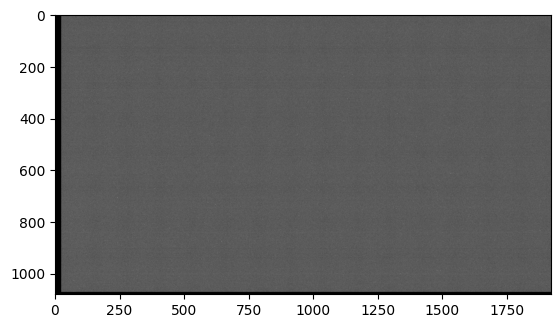

In [10]:
## OBS Virtual Camera (Make sure its on and that you have the correct name)
%matplotlib inline
def clear_interface():
    plt.close('all')
    clear_output(wait=True)

cap = RealtimeVideoCapture(1)  # Change to whatever index your OBS camera is. 
time.sleep(1)

clear_interface()
plt.imshow(cap.mean_capture(10, convert_to_grayscale=False))
plt.show()

In [11]:
flc = FirstLightController(pm, stg)
cac = ChipAlignmentController(stg, cap)
fence = SoftwareFence(stg, cap)

### CHIP ALIGNMENT

In [28]:
# CHIP ALIGNMENT
## Move chip (and camera) so that the top or bottom calibration patterns are visible in the camera, roughly in the middle.
stg.set_speed('m', 9)
stg.move_relative('m', 'X', -80, wait=True)# -9000 (up) or 9000 (down) to move it

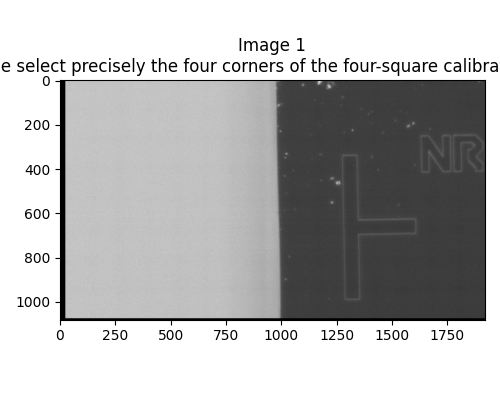

In [30]:
## Run to open template selection widget and draw a bounding box around the pattern or alignment mark.
%matplotlib widget

img = cap.mean_capture(20)
clear_interface()
cac.new_template_selection(img)

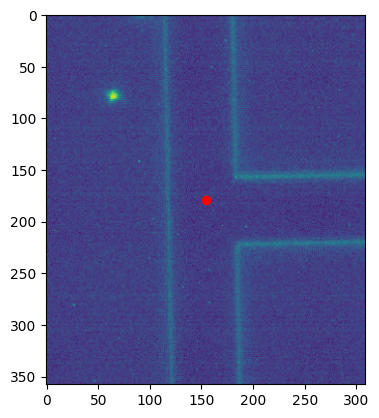

In [31]:
## Save the template to the alignment controller
%matplotlib inline

template_image = cac.generate_template(img)
clear_interface()
plt.imshow(template_image)
plt.scatter(template_image.shape[1] / 2, template_image.shape[0] / 2, c='r')
plt.show()

In [665]:
# move the chip to see the other alignment mark and bring it back
stg.set_speed('m', 9)
stg.move_relative('m', 'X',100, wait=True)# -10000 or 10000, TFLN 9000, b/w adjacent wvgs 6 um; wvg sets 381um
#remember to move it back and not to redefine the template

Starting Calibration Movement...
Calibration movement done. Starting main movement...
All images aquired. Moving back to starting position.
Matching calibration centers...
Generating visualization of calibration centers...
Calculating rotation...
Done. Optimal rotation is 0.0115 degrees.


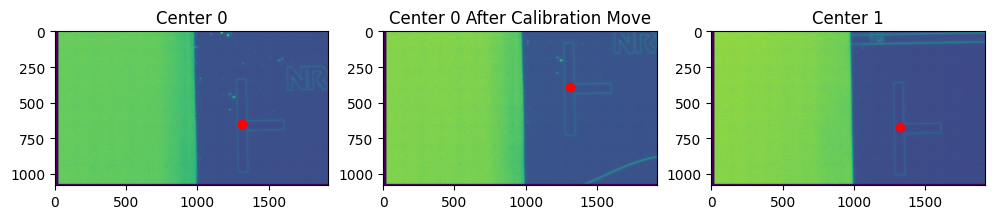

In [32]:
%matplotlib inline
## Select your movement values and perform chip alignment.
# Large movement should be roughly the length of the chip (1 cm works well), small calibration movement should be a few hundred microns.
#   - Make sure that the small movement doesn't bring your calibration pattern out of frame
# The sign of the movements should be positive for moving from top to bottom, and negative for moving bottom to top.


mainX = 9_300  # main movement (width of chip), 10_000 original
calX = 80  # calibration movement, 500 before
deg = cac.run_angle_calibration(mainX, calX, camera_focus_prompt=True) 

In [33]:
## If angle seems reasonable, rotate to align chip
# Check the pattern centers in the images for reasonableness
stg.move_relative_rotation(deg) # deg

In [10]:
# move the chip to first waveguide
stg.set_speed('m', 9)
stg.move_relative('m', 'X', -10, wait=True)


### STAGE CONTROL GUI (manual jog panel)

For coarse fiber and chip alignment 

Type a distance (microns) for each fiber axis and click Move, or use the chip step/direction toggles.

In [12]:
stage_gui = StageControlGUI(stg)
stage_gui.display()

### Helper functions - no need to run unless the kernel restarts

In [13]:
# All alignment/scan helper functions now live in src/AutoAlignController.py
# (see WaveguideAlignmentController, instantiated below once the switch is connected).
# These two thin aliases are kept only because a few of the manual cells below still
# call them directly by name.
def pdToPow(x, g):
    return WaveguideAlignmentController.pd_to_pow(x, g)

def logPDtoPow(Vout):
    return WaveguideAlignmentController.log_pd_to_pow(Vout)


FIRST LIGHT

### raster scan - do separately for 'l' and 'r'

In [14]:
# Broad scan, femto detector (manual diagnostic / first-light check)
aligner.switch_route('1', '1')
aligner.set_channel('ai0')

### Broad scan, can make it small scan with generate_linear_spiral((5, 5), 10)
stage = 'r'
speed = 7  # Speed setting from 0-9. Higher is only faster to a point.

# For first light, broad range scan ((40, 40), 80)
broad_range = False
if broad_range == True:
    commands = aligner.flc.pgen.generate_linear_spiral((10, 10), 20)    # params are scan dimension (should be x,y) and number of steps., (10,10,20)
else:
    commands = aligner.flc.pgen.generate_linear_spiral((5, 5), 10)    # params are scan dimension (should be x,y) and number of steps., (10,10,20)
result = aligner.flc.scan_path(stage, commands, speed, [0, 1, 2], perform_regression = True)

datapoints = result['datapoints']

# Not plotting the distribution
fig = result['figure']

## Maximum point delta
max_point = datapoints[
    np.argmax(datapoints[:, 2])
][:2]
print(f"Maximum: {max_point}")

fig.show()


AIChannel(name=Dev1/ai0)
Connected to: NI DAQ, Dev1, USB-6363 (BNC)
Starting motion...


Current Move: (Y, -5.0): 100%|██████████| 20/20 [00:03<00:00,  6.55item/s]


Returning to original position...
Fitting gaussian regression to datapoints...
Found optimal parameters.
Mean: [1.9282967  9.64476193]
Cov: [[ 771.70819329  776.62206471]
 [ 776.62206471 6052.82028451]]
Maximum: [ 1.03399433 -2.        ]


In [116]:
# Move to the gaussian fit mean

mean = result['mean']
stg.move_relative(stage, 'X', mean[0])#mean[0])
stg.move_relative(stage, 'Y', mean[1])#mean[1])
print(f"Moved to {mean}")

Moved to [0.08957408 0.0353755 ]


### GUI for raster and z-scan after the first broad raster scan

In [20]:
importlib.reload(src.ScanGUI)
from src.ScanGUI import ScanControlGUI

In [21]:
aligner.switch_route('1', '1')
aligner.set_channel('ai0') 

scan_gui = ScanControlGUI(aligner)
scan_gui.display()

AIChannel(name=Dev1/ai0)
Connected to: NI DAQ, Dev1, USB-6363 (BNC)


### z-translation - do separately for 'l' and 'r'

In [111]:
## Z fine-tuning (manual diagnostic)
stage = 'r'
speed = 6

# Enter a list of relative commands manually, comes back to original position
commands = [
    ['Z', 2],#2
    ['Z', -6], #-8
]
result = aligner.flc.scan_path(stage, commands, speed, [0, 1, 2], perform_regression = False)

datapoints = result['datapoints']
fig = result['figure']

## Maximum point delta
max_point = datapoints[
    np.argmax(datapoints[:, 2])
][:2]

fig.show()


Starting motion...


Current Move: (Z, -6.0): 100%|██████████| 2/2 [00:00<00:00,  5.01item/s]

Returning to original position...


0.00625


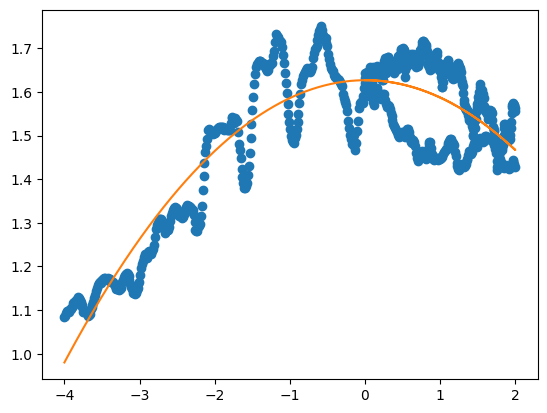

In [112]:
# do the same raster scan for 'r'
z_tun = datapoints[:,0]
Pz_tun = datapoints[:,2]

plt.plot(z_tun, Pz_tun, 'o')

[fitparams, fitcov] = curve_fit(aligner.parabola, z_tun, Pz_tun) # p0
fitcov
fit_par = aligner.parabola(z_tun, *fitparams)

plt.plot(z_tun, fit_par)
print(z_tun[np.argmax(fit_par)])
stg.move_relative(stage, 'Z', z_tun[np.argmax(fit_par)], wait=True)


### Defining folder for saving, change chip folder - Important!!!!

In [29]:
# folder_dir = "C:/Users/Pooja/Documents/Pooja/OneDrive - NTT Research Inc/Documents/Die testing/Insertion_loss_transfer_function/TFLN08_SCG-1/"
folder_dir = "C:/Users/Pooja/Documents/Pooja/OneDrive - NTT Research Inc/Documents/Die testing/Insertion_loss_transfer_function/SCG002/"
# chip_no = input("Enter chip number: ").strip()
# folder_name = f"chip{chip_no}"

'''
New wafer measurement
'''
chip_no = 'C07D02'

folder_path = folder_dir + chip_no

# Create directories if they don't exist
os.makedirs(folder_path, exist_ok=True)

file_path = os.path.join(folder_path, "insertion_loss.csv")

with open(file_path, mode="w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["Device no", "IL (dB)"])

### Running all waveguides on a chip 

AIChannel(name=Dev1/ai0)
Connected to: NI DAQ, Dev1, USB-6363 (BNC)
Starting motion...


Current Move: (Y, -20.0): 100%|██████████| 80/80 [00:10<00:00,  7.61item/s]


Returning to original position...
Moved to [np.float64(0.058869012633818836), np.float64(-0.059070964338635804)]
Max is:  1.7834459354798073
Starting motion...


Current Move: (Y, -20.0): 100%|██████████| 80/80 [00:10<00:00,  7.34item/s]


Returning to original position...
Moved to [np.float64(0.034581356513245017), np.float64(-0.021868228593237345)]
Max is:  1.7919735819866482
AIChannel(name=Dev1/ai1)
Connected to: NI DAQ, Dev1, USB-6363 (BNC)
Starting motion...


...

Current Move: (Z, -5.0): 100%|██████████| 2/2 [00:00<00:00,  6.67item/s]


Returning to original position...
-0.07843137254901977
Starting motion...


Current Move: (Y, -5.0): 100%|██████████| 20/20 [00:02<00:00,  8.68item/s]


Returning to original position...
Moved to [np.float64(0.014466112753130008), np.float64(0.13490940190205458)]
Max is:  2.0862580968437414
66, Insertion loss- -13.424715341157258
Connected to: NI DAQ, Dev2, USB-6363 (BNC)
200


c:\Users\Pooja\Documents\GitHub\Three-wave-mixing\twm.venv\Lib\site-packages\nidaqmx\task\_task.py:128: DaqResourceWarning: Task of name "_unnamedTask<178>" was not explicitly closed before it was destructed. Resources on the task device may still be reserved.
  warnings.warn(


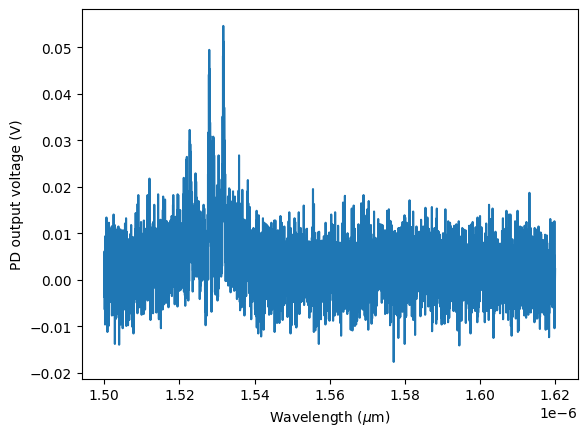

In [117]:
# Step through every waveguide on the chip: auto-align first light on both fibers,
# record insertion loss to file_path, measure + save a transfer function for each
# successfully-aligned waveguide, and advance the chip stage in between.
#
# device_no runs 2..66 to match the original loop (`for i in range(1, 66): device_no = i+1`).
z_trans_l, z_trans_r = aligner.run_all_waveguides(
    first_device_no=11,
    last_device_no=66,
    file_path=file_path,
    z_trans_l=z_trans_l,
    z_trans_r=z_trans_r,
    threshold=0.02,
    measure_transfer_function=True,
    tsl770=TSL770,
    daq_factory=USB6363,
    folder_path=folder_path,
    wavelength=1560e-9,
)


#### move the chip back to device 66

In [75]:
# # move the chip to the next waveguide
stg.set_speed('m', 9)
stg.move_relative('m', 'X', 254-8, wait=True) #381

#### One waveguide at a time - checking insertion loss

In [ ]:
device_no = 3

In [ ]:
'''
Aligning at 1560 nm (single waveguide, manual test of the auto-align routine)
'''

result = aligner.align_waveguide(device_no, z_trans_l, z_trans_r, threshold=0.02)
device_no = result['device_no']
il = result['il']
z_trans_l = result['z_trans_l']
z_trans_r = result['z_trans_r']
print('Insertion loss- ', il)


### Skip the next two blocks 

Initialize daq, do transfer function measurement and save

In [ ]:
# change to Si PD before TWM
aligner.switch_route('1', '3')
ai_channel = 'ai2'

daq = USB6363()
# Add Analog input channels, 4 - Si, 5 - TSL770
daq.ai_task = nidaqmx.Task()
daq.ai_task.ai_channels.add_ai_voltage_chan("Dev2/ai5, Dev2/ai4, Dev2/ai0")

aligner.measure_transfer_function(TSL770, daq, folder_path, device_no)

daq.close()


#### check if laser wavelength is 1560 nm; changing laser wavelength to 1560 nm

In [ ]:
TSL770.wavelength(1560e-9)
time.sleep(0.5)

### Once the data is all saved, close file and close devices

In [ ]:
f.close()
TSL770.close()
switch.close()

#### Move back the fibers by 10000

In [118]:
stg.move_relative('r', 'z', -10000, wait=True)

In [119]:
stg.move_relative('l', 'z', -10000, wait=True)

#### convert SHG voltages to power

In [ ]:
gain = 3e4
R = 0.45 # V/mW
shg_pow = shg_v/(gain * R)

# calculating conversion efficiency
pf = inp_pow*1e-3 * 10**-0.75 # IL approx 15 dB throughput
pshg = 2.296e-9/10**-0.8 # newly measured 8 dB
l = 6e-3
pshg/(pf**2 * l**2) * 100 # in %